# FL16Y spectral fitting

In [1]:
%run pylib/tools dark
from pathlib import Path

from astropy.coordinates import SkyCoord
from utilities.ipynb_docgen import show, show_date
from pylib.pixel_table import PixelTable
# from pylib.fl16y_spectral_fit import fit_fl16y_power_law, plot_fl16y_fit
from like3.sourcelist import SourceModel

show_date()

pixel_table_file = Path('files/kerr/toby_v4_exposure.fits')
if not pixel_table_file.exists():
    raise FileNotFoundError(
        f'{pixel_table_file} not found. Run exposure_fl16y.ipynb first to create the exposure-attached pixel table.'
    )
pt = PixelTable(pixel_table_file)

<h5 style="text-align:right; margin-right:15px"> 2026-04-01 15:07</h5>

Loaded pixel table from "files/kerr/toby_v4_exposure.fits":
            43 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            206,555,017 photons
            8,241,643 pixels
            


## Build a SourceModel From a Fermi catalog subset

Use the checked-in 4FGL catalog to create a compact ROI source model around a trial position. This supports the new `SourceModel.from_fermi_catalog(...)` entry point with spatial filtering, `query=`, and explicit `select=`.

In [2]:
from importlib import reload

from utilities.catalogs import Fermi4FGL
from like3 import sourcelist as sourcelist_mod

reload(sourcelist_mod)
SourceModel = sourcelist_mod.SourceModel

# catalog_path = Path('/home/burnett/wtlike-data/gll_psc_v32.fit')
# if not catalog_path.exists():
#     raise FileNotFoundError(f'{catalog_path} not found')

catalog = Fermi4FGL('uw1617' )#path=str(catalog_path))
source_position = SkyCoord.from_name('MRK 501')

roi_sources = SourceModel.from_fermi_catalog(
    catalog=catalog,
    skydir=source_position,
    cone_size=5.0,
    query='significance >= 25',
)

selected_name = roi_sources.source_names[0]
selected_sources = SourceModel.from_fermi_catalog(
    catalog=catalog,
    select=[selected_name],
)

show(
    f'''Loaded {len(roi_sources)} catalog sources within 5 deg of {source_position.to_string("decimal", precision=3)}.
First selected source: {selected_name}'''
)

roi_sources.source_names[:8], selected_sources.source_names

Loaded Fermi 4FGL gll_pscP305uw1617_v4_assoc_v9r1_classes.fits: 7221 entries


Loaded 6 catalog sources within 5 deg of 253.468 39.760.
First selected source: FL16Y07615

(array(['FL16Y07615', 'FL16Y07684', 'FL16Y07717', 'FL16Y07777', 'FL16Y07836', 'FL16Y08061'], dtype='<U10'),
 array(['FL16Y07615'], dtype='<U10'))

## Build a BandList using a pixel table

In [3]:
from importlib import reload

import numpy as np
from like3 import bands as bands_mod; reload(bands_mod)
BandList = bands_mod.BandList

bandlist = BandList.from_pixel_table(selected_sources, pt)

first_pixel_band = next(iter(pt.values()))
saved_sparse_exposure = getattr(first_pixel_band, 'pixel_exposure', None)
if saved_sparse_exposure is None:
    raise ValueError('Loaded PixelTable does not contain saved sparse pixel exposure')

probe_pix = np.asarray(first_pixel_band.pix[: min(3, len(first_pixel_band.pix))], dtype=int)
saved_probe = np.asarray(saved_sparse_exposure[: probe_pix.size], dtype=float)
bandlist_probe = bandlist[0].exposure_map(probe_pix)
np.testing.assert_allclose(bandlist_probe, saved_probe)

show(
    f'''Constructed BandList for {selected_sources.source_names[0]} from PixelTable {pt.name}
Bands: {len(bandlist)}
First band: {bandlist[0]}
Exposure source: saved sparse pixel exposure
Checked pixels: {probe_pix.tolist()}
Saved exposure sample: {saved_probe.tolist()}'''
)

bandlist[:3]

Constructed BandList for FL16Y07615 from PixelTable toby_v4_exposure
Bands: 43
First band: Band(energy=1333.5 MeV, et=2 nside=64)
Exposure source: saved sparse pixel exposure
Checked pixels: [0, 1, 2]
Saved exposure sample: [247922515968.0, 250032013312.0, 246993068032.00003]

[Band(energy=1333.5 MeV, et=2 nside=64),
 Band(energy=2371.4 MeV, et=2 nside=64),
 Band(energy=4217.0 MeV, et=2 nside=128)]

In [4]:
b = bandlist[5]
b.pixel_counts()

(array([127683, 126675, 125670, 126674, 127682, 128695, 129712, 128696, 127684, 126676, 125671, 129713, 128697, 127685,
        126677, 125672, 129714, 128698, 127686, 126678, 125673, 129715, 128699, 127687, 126679, 125674, 129716, 128700,
        127688, 129717, 130737, 130736, 131761, 131760, 132784, 132783, 133808, 133807, 131759, 132782, 133806, 134830,
        134829, 132781, 133805, 131757, 132780, 133804, 131756, 132779, 130731, 131755, 132778, 130730, 131754, 129709,
        130729, 128692, 129708, 127679, 128691, 126670, 125666, 126671, 125667, 124666, 127680, 126672, 125668, 124667,
        128693, 127681, 126673, 125669, 124668, 128694, 129710, 129711, 130732, 130733, 131758, 130734, 130735, 123672,
        122679, 123671, 124669, 123673, 122680, 124670, 123674, 122681, 124671, 123675, 122682, 124672, 123676, 124673,
        121693, 121692, 121691, 121690, 122678, 123670]),
 array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00

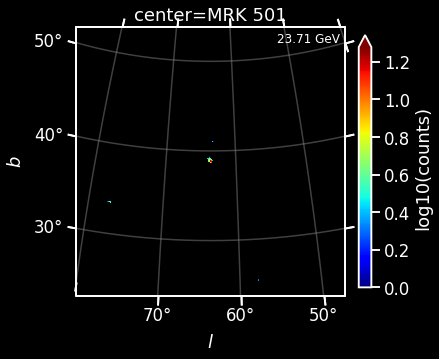

In [5]:
from importlib import reload
from like3 import bands as bands_mod; reload(bands_mod)
# b.__class__ = bands_mod.Band
# b.order = 'nested'  # b was built before fix; remove once bandlist is rebuilt
b.plot_pixel_map(SkyCoord.from_name('MRK 501'), size=30, data=b.data, title='center=MRK 501')

In [6]:
b.energy

23713.737056616552

In [7]:

import numpy as np
k, v = b.pixel_counts()
from astropy_healpix import HEALPix
from astropy.coordinates import SkyCoord
hpx = HEALPix(nside=int(b.nside), order='ring', frame='galactic')
coords = hpx.healpix_to_skycoord(k)
print(f"pixel_counts: {len(k)} pixels")
for pix, cnt, l, bv in zip(k, v, coords.galactic.l.deg, coords.galactic.b.deg):
    print(f"  pix={pix:5d}  v={cnt:.4f}  l={l:.2f}  b={bv:.2f}")
for src in b.source_model:
    gal = src.skydir.galactic
    print(f"\n{src.name} position: l={gal.l.deg:.3f} b={gal.b.deg:.3f}")
mrk = SkyCoord.from_name('MRK 501')
print(f"MRK 501:       l={mrk.galactic.l.deg:.3f} b={mrk.galactic.b.deg:.3f}")


pixel_counts: 104 pixels
  pix=127683  v=0.0000  l=61.01  b=42.41
  pix=126675  v=0.0000  l=61.25  b=42.61
  pix=125670  v=0.0000  l=61.14  b=42.81
  pix=126674  v=0.0000  l=60.89  b=42.61
  pix=127682  v=0.0000  l=60.65  b=42.41
  pix=128695  v=0.0000  l=60.77  b=42.21
  pix=129712  v=0.0000  l=60.88  b=42.01
  pix=128696  v=0.0001  l=61.12  b=42.21
  pix=127684  v=0.0000  l=61.36  b=42.41
  pix=126676  v=0.0000  l=61.61  b=42.61
  pix=125671  v=0.0000  l=61.49  b=42.81
  pix=129713  v=0.0000  l=61.24  b=42.01
  pix=128697  v=0.0000  l=61.48  b=42.21
  pix=127685  v=0.0000  l=61.72  b=42.41
  pix=126677  v=0.0000  l=61.96  b=42.61
  pix=125672  v=0.0000  l=61.85  b=42.81
  pix=129714  v=0.0000  l=61.59  b=42.01
  pix=128698  v=0.0000  l=61.83  b=42.21
  pix=127686  v=0.0000  l=62.08  b=42.41
  pix=126678  v=0.0000  l=62.32  b=42.61
  pix=125673  v=0.0000  l=62.21  b=42.81
  pix=129715  v=0.0000  l=61.94  b=42.01
  pix=128699  v=0.0000  l=62.19  b=42.21
  pix=127687  v=0.0000  l=62.43 